# Variational Autoencoder (VAE) - TensorFlow / Keras


Train Shape: (60000, 784)
Test Shape : (10000, 784)

Encoder Summary:


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 400)       │    314,000 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu (Dense)          │ (None, 20)        │      8,020 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 20)        │      8,020 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_3          │ (None, 20)        │          0 │ mu[0][0],         │
│ (Sampling)          │                   │            │ log_var[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 330,040 (1.26 MB)

 Trainable params: 330,040 (1.26 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 400)            │         8,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 784)            │       314,384 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,784 (1.23 MB)

 Trainable params: 322,784 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - kl_loss: 18.5543 - loss: 163.9675 - reconstruction_loss: 145.4132 - val_kl_loss: 21.7631 - val_loss: 128.4117 - val_reconstruction_loss: 106.6486
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - kl_loss: 22.7734 - loss: 122.3790 - reconstruction_loss: 99.6056 - val_kl_loss: 23.7880 - val_loss: 116.5767 - val_reconstruction_loss: 92.7886
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - kl_loss: 24.0293 - loss: 115.4969 - reconstruction_loss: 91.4675 - val_kl_loss: 23.9204 - val_loss: 112.8073 - val_reconstruction_loss: 88.8870
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - kl_loss: 24.5537 - loss: 112.3860 - reconstruction_loss: 87.8323 - val_kl_loss: 24.8987 - val_loss: 110.4162 - val_reconstruction_loss: 85.5175
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - kl_loss: 24.7848 - loss: 110.4596 - reconstruction_loss: 85.6748 - val_kl_loss: 25.0118 - val_loss: 108.7971 - val_reconstruction_loss: 83.785

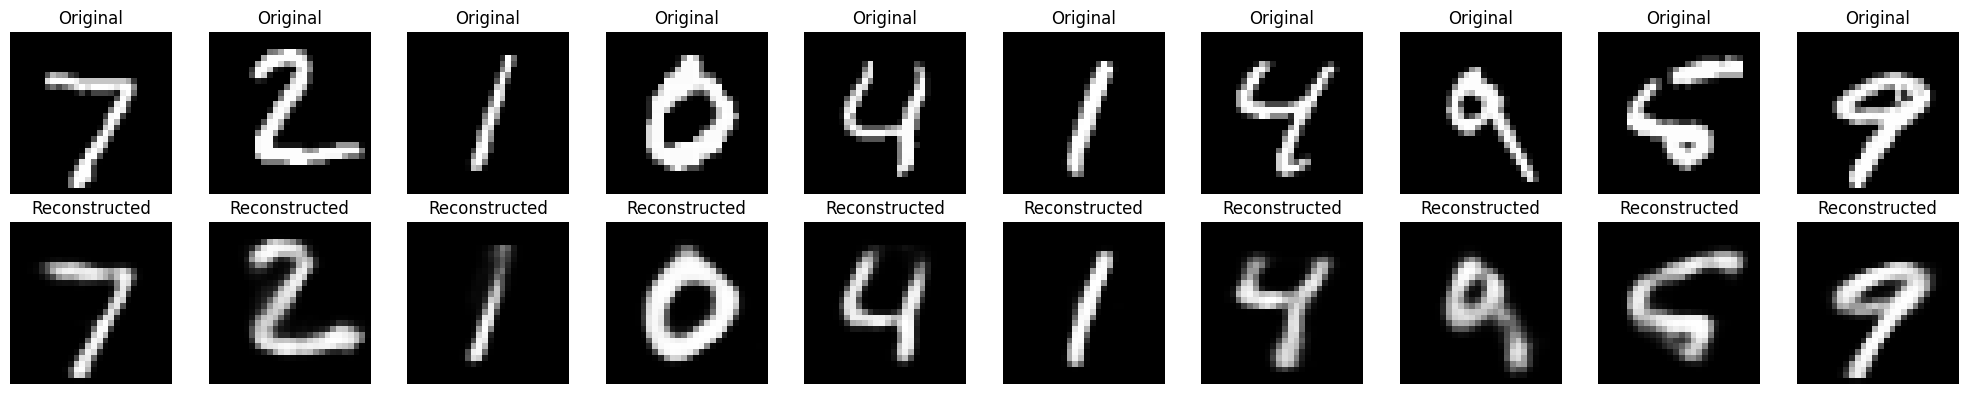

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


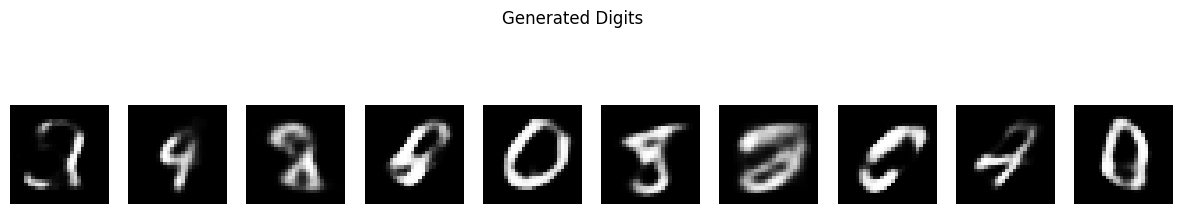


Models saved successfully!


In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# =========================================================
# 1. Load MNIST Dataset
# =========================================================

(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Train Shape:", x_train.shape)
print("Test Shape :", x_test.shape)

# =========================================================
# 2. Hyperparameters
# =========================================================

INPUT_DIM = 784
HIDDEN_DIM = 400
LATENT_DIM = 20
BATCH_SIZE = 128
EPOCHS = 20

# =========================================================
# 3. Sampling Layer
# =========================================================

class Sampling(layers.Layer):
    def call(self, inputs):
        mu, log_var = inputs
        batch = tf.shape(mu)[0]
        dim = tf.shape(mu)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return mu + tf.exp(0.5 * log_var) * epsilon

# =========================================================
# 4. Build Encoder
# =========================================================

encoder_inputs = keras.Input(shape=(INPUT_DIM,))

x = layers.Dense(HIDDEN_DIM, activation="relu")(encoder_inputs)
mu = layers.Dense(LATENT_DIM, name="mu")(x)
log_var = layers.Dense(LATENT_DIM, name="log_var")(x)

z = Sampling()([mu, log_var])

encoder = keras.Model(encoder_inputs, [mu, log_var, z], name="encoder")

print("\nEncoder Summary:")
encoder.summary()

# =========================================================
# 5. Build Decoder
# =========================================================

latent_inputs = keras.Input(shape=(LATENT_DIM,))

x = layers.Dense(HIDDEN_DIM, activation="relu")(latent_inputs)
decoder_outputs = layers.Dense(INPUT_DIM, activation="sigmoid")(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

print("\nDecoder Summary:")
decoder.summary()

# =========================================================
# 6. Define VAE Model
# =========================================================

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

        # Loss tracker metrics
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

        # BCE loss
        self.bce = keras.losses.BinaryCrossentropy()

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    # =====================================================
    # Forward Pass
    # =====================================================
    def call(self, inputs):
        mu, log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    # =====================================================
    # Compute Loss
    # =====================================================
    def compute_vae_loss(self, data):
        # Encode
        mu, log_var, z = self.encoder(data)

        # Decode
        reconstruction = self.decoder(z)

        # Reconstruction loss
        reconstruction_loss = self.bce(data, reconstruction) * INPUT_DIM

        # KL divergence
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + log_var - tf.square(mu) - tf.exp(log_var),
                axis=1
            )
        )

        # Total loss
        total_loss = reconstruction_loss + kl_loss

        return total_loss, reconstruction_loss, kl_loss

    # =====================================================
    # Train Step
    # =====================================================
    def train_step(self, data):
        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss, kl_loss = self.compute_vae_loss(data)

        # Compute gradients
        grads = tape.gradient(total_loss, self.trainable_weights)

        # Apply gradients
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    # =====================================================
    # Validation Step (IMPORTANT FIX)
    # =====================================================
    def test_step(self, data):
        total_loss, reconstruction_loss, kl_loss = self.compute_vae_loss(data)

        # Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# =========================================================
# 7. Create VAE
# =========================================================

vae = VAE(encoder, decoder)

# =========================================================
# 8. Compile Model
# =========================================================

vae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

# =========================================================
# 9. Train Model
# =========================================================

history = vae.fit(
    x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, None)
)

# =========================================================
# 10. Reconstruct Images
# =========================================================

mu, log_var, z = encoder.predict(x_test)
reconstructed_images = decoder.predict(z)

# =========================================================
# 11. Visualize Reconstructions
# =========================================================

n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_images[i].reshape(28, 28), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

# =========================================================
# 12. Generate New Images
# =========================================================

random_latent_vectors = tf.random.normal(shape=(10, LATENT_DIM))
generated_images = decoder.predict(random_latent_vectors)

# =========================================================
# 13. Visualize Generated Digits
# =========================================================

plt.figure(figsize=(15, 3))

for i in range(10):
    ax = plt.subplot(1, 10, i + 1)
    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("Generated Digits")
plt.show()

# =========================================================
# 14. Save Models (Optional)
# =========================================================

encoder.save("vae_encoder.keras")
decoder.save("vae_decoder.keras")
print("\nModels saved successfully!")

### VAE Objective

The VAE minimizes:

$$\mathcal{L} = \text{Reconstruction Loss} + D_{KL}(q(z|x)\parallel p(z))$$

KL divergence:

$$D_{KL} = -\frac{1}{2}\sum(1 + \log(\sigma^2) - \mu^2 - \sigma^2)$$
